# JWST MIRI Photometry Extraction & Visualization

## Read the data

In [1]:
from astropy.io import fits

# 1. Open the file 
file_path = 'MIRI\cos87259_F560W_60mas.fits.gz'
hdul = fits.open(file_path)

# 2. View the overall structure of HDUs in this file
print("File Information:")
hdul.info()
print("-" * 40)

# 3. Access a specific Extension (e.g., 'SCI' for Science)
sci_header = hdul['SCI'].header
sci_data = hdul['SCI'].data

# 4. Read the first 10 lines of the Header to understand metadata
print("First 10 Header Keywords:")
print(list(sci_header.items())[:10])
print("-" * 40)

# 5. Check the shape of the Data array
# For 3D IFU Spectra, it's (Wavelength, Y_Pixels, X_Pixels)
print("Data Shape:", sci_data.shape)

# Close the file when done to save memory
hdul.close()

File Information:
Filename: MIRI\cos87259_F560W_60mas.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     350   ()      
  1  SCI           1 ImageHDU        75   (2633, 2518)   float32   
  2  ERR           1 ImageHDU        10   (2633, 2518)   float32   
  3  CON           1 ImageHDU        10   (2633, 2518, 1)   int32   
  4  WHT           1 ImageHDU         9   (2633, 2518)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (2633, 2518)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (2633, 2518)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (2633, 2518)   float32   
  8  HDRTAB        1 BinTableHDU    500   4R x 245C   [23A, 5A, 3A, 75A, 6A, 13A, 4A, 5A, 6A, 7A, 10A, 4A, L, D, D, 4A, 15A, 109A, 13A, 2A, 44A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 12A, 4A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 9A, 9A, 5A, D, D, D, D, D, D, D, D, 4A, 8A, 5A, 4A, 3A, 4A, K, 5A, 9A, D, D, D, D, D, D, D, D

In [2]:
import numpy as np
from astropy.io import fits
from astropy import wcs
import sep
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

miri_dir = 'd:/Fudan_University/Research/JWST/MIRI'
output_dir = 'd:/Fudan_University/Research/JWST/extracted_photometry'
os.makedirs(output_dir, exist_ok=True)

# Define clump parameters from the original notebook
clump_ids = ['Center', 'West', 'North', 'South', 'Southeast']
x_ifu = np.array([27.2994, 27.2994, 27.5317, 26.9051, 19.7599]) 
y_ifu = np.array([24.2436, 24.2436, 28.4938, 15.3950, 20.7517]) 
a_ifu = np.array([2.0362, 2.0362, 1.4309, 3.2745, 2.0370]) 
b_ifu = np.array([1.4896, 1.4896, 1.3812, 1.0209, 1.0339]) 
r_ifu = np.array([2.6471, 2.6471, 3.2883, 2.5689, 2.2962]) 
theta_ifu = np.array([-0.1644, -0.1644, -0.0619, -0.3366, 0.9059]) 

In [3]:
# We need the WCS from the IFU to map these pixel coordinates to Sky coordinates
ifu_file = 'd:/Fudan_University/Research/JWST/NIRSpec_IFU/COS-87259_NOBG_prism-clear_s3d.fits'
ifu_hdul = fits.open(ifu_file)
ifu_wcs = wcs.WCS(ifu_hdul['SCI'].header).celestial

# Convert IFU pixel coordinates to sky coordinates (RA, Dec)
ra_clumps, dec_clumps = ifu_wcs.pixel_to_world_values(x_ifu, y_ifu)

bands = ['F560W', 'F770W', 'F1000W', 'F1130W', 'F1280W', 'F1500W', 'F1800W', 'F2100W', 'F2550W']
results = []

Set DATE-AVG to '2025-04-14T04:29:54.763' from MJD-AVG.
Set DATE-END to '2025-04-14T05:08:41.715' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -11.312414 from OBSGEO-[XYZ].
Set OBSGEO-H to 1397161713.742 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


## Extracting and Visualizing Apertures for All 9 Bands


Processing MIRI band: F560W
    Center: Flux=1.82 uJy
    West: Flux=1.82 uJy
    North: Flux=1.85 uJy
    South: Flux=0.24 uJy
    Southeast: Flux=0.23 uJy


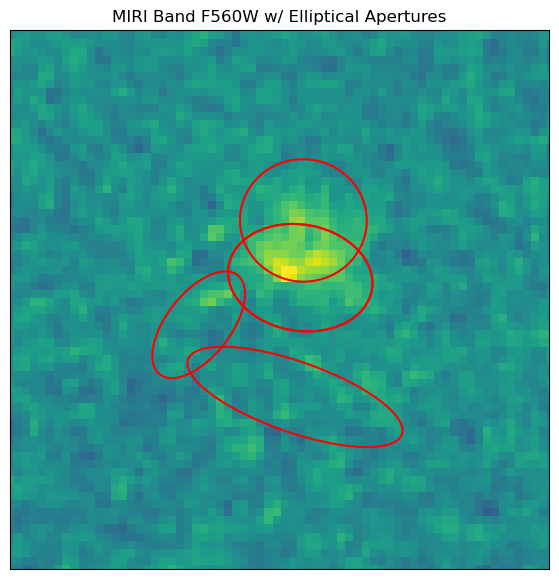


Processing MIRI band: F770W
    Center: Flux=2.45 uJy
    West: Flux=2.45 uJy
    North: Flux=2.39 uJy
    South: Flux=0.15 uJy
    Southeast: Flux=0.21 uJy


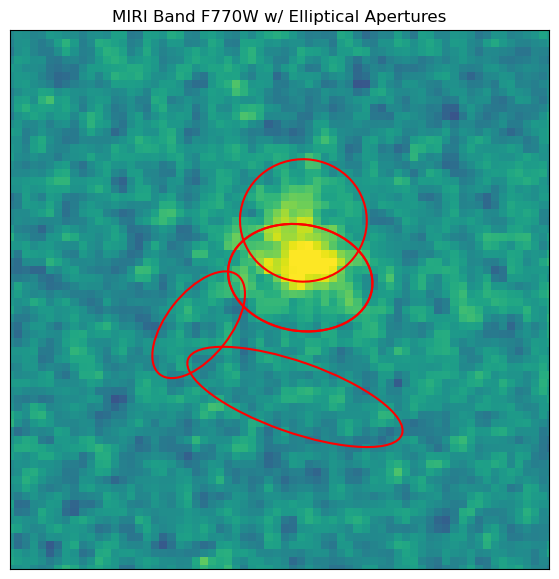


Processing MIRI band: F1000W
    Center: Flux=3.55 uJy
    West: Flux=3.55 uJy
    North: Flux=3.54 uJy
    South: Flux=-0.34 uJy
    Southeast: Flux=0.32 uJy


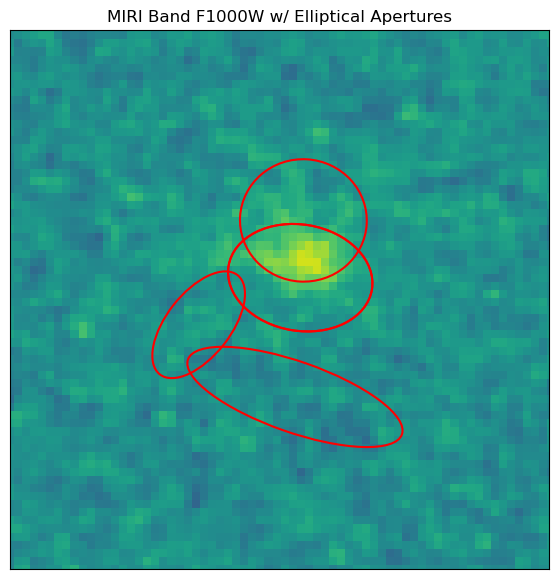


Processing MIRI band: F1130W
    Center: Flux=4.57 uJy
    West: Flux=4.57 uJy
    North: Flux=3.88 uJy
    South: Flux=0.73 uJy
    Southeast: Flux=0.39 uJy


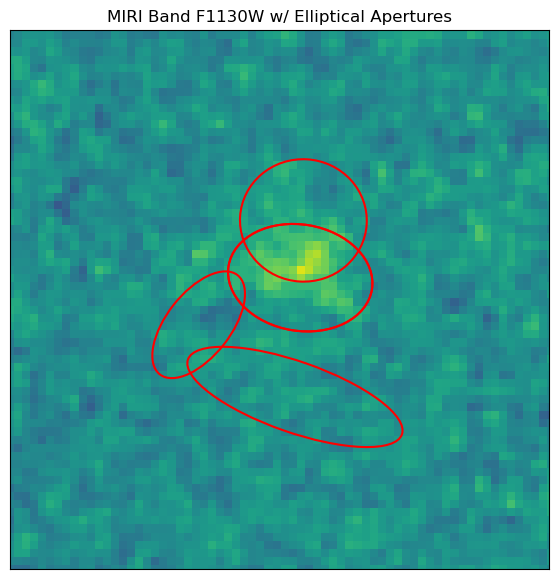


Processing MIRI band: F1280W
    Center: Flux=6.74 uJy
    West: Flux=6.74 uJy
    North: Flux=5.92 uJy
    South: Flux=0.37 uJy
    Southeast: Flux=0.58 uJy


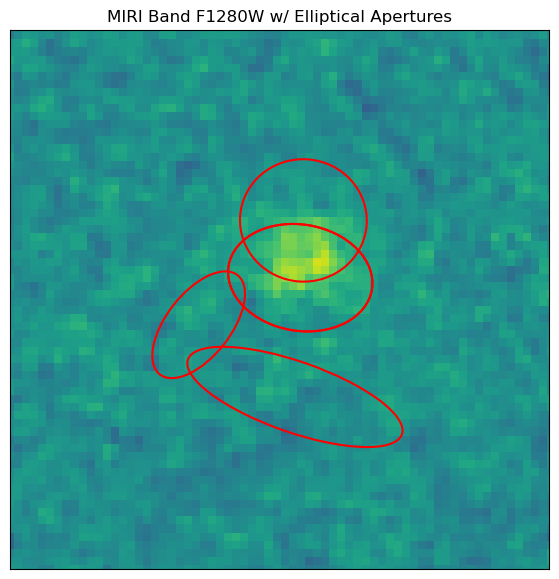


Processing MIRI band: F1500W
    Center: Flux=12.91 uJy
    West: Flux=12.91 uJy
    North: Flux=10.99 uJy
    South: Flux=-0.06 uJy
    Southeast: Flux=0.96 uJy


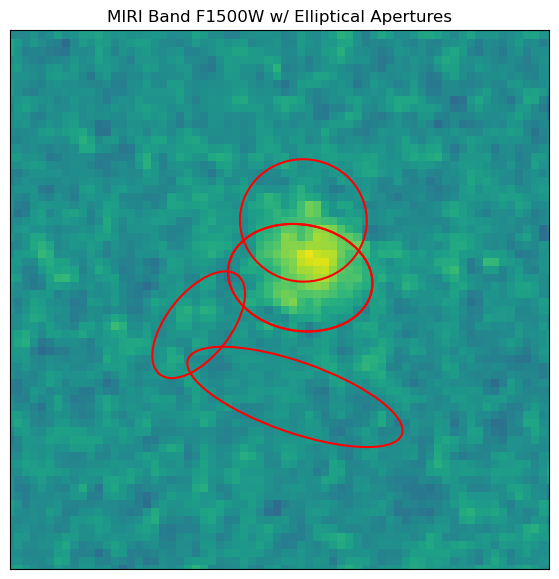


Processing MIRI band: F1800W
    Center: Flux=28.23 uJy
    West: Flux=28.23 uJy
    North: Flux=19.11 uJy
    South: Flux=2.74 uJy
    Southeast: Flux=0.50 uJy


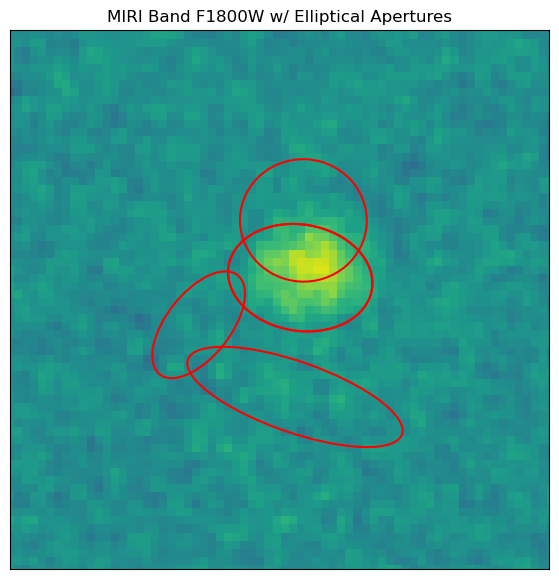


Processing MIRI band: F2100W
    Center: Flux=42.74 uJy
    West: Flux=42.74 uJy
    North: Flux=38.68 uJy
    South: Flux=1.98 uJy
    Southeast: Flux=-1.21 uJy


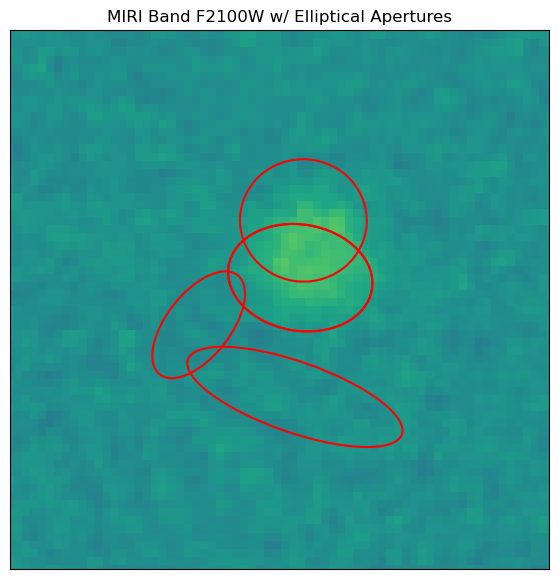


Processing MIRI band: F2550W
    Center: Flux=74.92 uJy
    West: Flux=74.92 uJy
    North: Flux=64.85 uJy
    South: Flux=-4.76 uJy
    Southeast: Flux=7.69 uJy


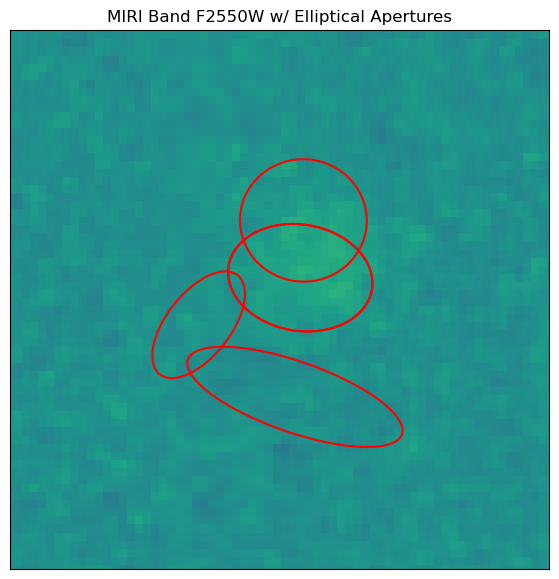

In [6]:
import warnings
warnings.filterwarnings('ignore') # Ignore some FITS WCS warnings for clean output

for band in bands:
    print(f"\nProcessing MIRI band: {band}")
    file_path = os.path.join(miri_dir, f'cos87259_{band}_60mas.fits.gz')
    
    if not os.path.exists(file_path):
        print(f"  Warning: File not found: {file_path}")
        continue
        
    with fits.open(file_path) as hdul:
        sci_data = hdul['SCI'].data
        err_data = hdul['ERR'].data
        header = hdul['SCI'].header
        
        miri_wcs = wcs.WCS(header)
        pixar_sr = header.get('PIXAR_SR', 1.0)
        
        # Find pixel coordinates in MIRI image for each clump
        x_miri, y_miri = miri_wcs.world_to_pixel_values(ra_clumps, dec_clumps)
        
        # Scale the aperture sizes from IFU pixels to MIRI pixels
        ifu_scale = np.sqrt(ifu_wcs.pixel_scale_matrix[0,0]**2 + ifu_wcs.pixel_scale_matrix[0,1]**2)
        miri_scale = np.sqrt(miri_wcs.pixel_scale_matrix[0,0]**2 + miri_wcs.pixel_scale_matrix[0,1]**2)
        scale_factor = ifu_scale / miri_scale
        
        a_miri = a_ifu * scale_factor
        b_miri = b_ifu * scale_factor
        r_miri = r_ifu 
        
        sci_data = sci_data.astype(sci_data.dtype.newbyteorder('='))
        err_data = err_data.astype(err_data.dtype.newbyteorder('='))
        
        nan_mask = np.isnan(sci_data)
        sci_data_clean = np.nan_to_num(sci_data, nan=0.0)
        err_data_clean = np.nan_to_num(err_data, nan=np.inf)
        
        # Plotting Setup
        plt.figure(figsize=(7, 7))
        m = np.nanmedian(sci_data)
        s = np.nanstd(sci_data)
        plt.imshow(sci_data_clean, origin='lower', vmin=m-s, vmax=m+s, cmap='viridis')
        
        # Zoom in to the clumps
        cx, cy = np.mean(x_miri), np.mean(y_miri)
        zoom = 20 * scale_factor # roughly 50 IFU pixels
        plt.xlim(cx - zoom, cx + zoom)
        plt.ylim(cy - zoom, cy + zoom)
        plt.title(f"MIRI Band {band} w/ Elliptical Apertures")
        
        for n, clump_id in enumerate(clump_ids):
            aper_flux, aper_flux_err, aper_flag = sep.sum_ellipse(
                sci_data_clean, [x_miri[n]], [y_miri[n]], [a_miri[n]], [b_miri[n]], [theta_ifu[n]], [r_miri[n]], 
                err=err_data_clean, mask=nan_mask
            )
            
            # Convert to microJansky (uJy)
            flux_ujy = aper_flux[0] * 1e6 * pixar_sr * 1e6 # MJy/sr -> Jy -> uJy
            flux_err_ujy = aper_flux_err[0] * 1e6 * pixar_sr * 1e6
            wl_obs = float(band.replace('W', '').replace('F', '')) / 100.0 # um
            
            res_dict = {
                'Clump ID': clump_id,
                'Band': band,
                'Wavelength_um': wl_obs,
                'Flux_uJy': flux_ujy,
                'Flux_Err_uJy': flux_err_ujy
            }
            results.append(res_dict)
            print(f"    {clump_id}: Flux={flux_ujy:.2f} uJy")
            
            # Draw Aperture
            e = Ellipse(xy=(x_miri[n], y_miri[n]), width=2.*a_miri[n]*r_miri[n], height=2.*b_miri[n]*r_miri[n], 
                        angle=theta_ifu[n]*180./np.pi, facecolor='none', edgecolor='red', lw=1.5)
            plt.gca().add_patch(e)
            #plt.text(x_miri[n] + 1.5, y_miri[n] + 1.5, clump_id, color='red', fontsize=10)
            
        plt.xticks([])
        plt.yticks([])
        plt.show()

## Saving Results

In [ ]:
# Save results
df = pd.DataFrame(results)
output_file = os.path.join(output_dir, 'miri_photometry.csv')
df.to_csv(output_file, index=False)
print(f"Extraction complete. Results saved to {output_file}")

## Photometric flux

MIRI SED plot saved to d:/Fudan_University/Research/JWST/extracted_photometry\miri_seds.png


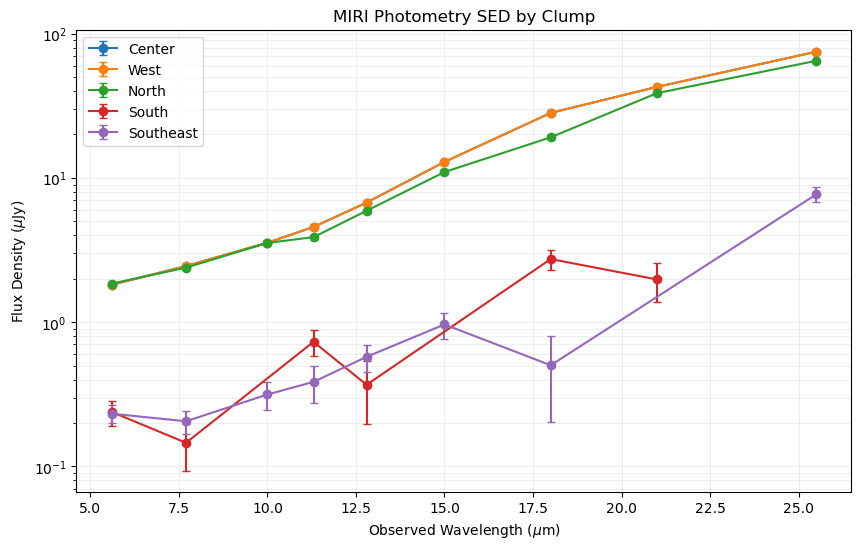

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

miri_file = 'd:/Fudan_University/Research/JWST/extracted_photometry/miri_photometry.csv'
output_dir = 'd:/Fudan_University/Research/JWST/extracted_photometry'

if not os.path.exists(miri_file):
    print("MIRI photometry file not found.")
    exit()

df = pd.read_csv(miri_file)

clumps = df['Clump ID'].unique()

plt.figure(figsize=(10, 6))

# Plot SED for each clump
for clump in clumps:
    clump_data = df[df['Clump ID'] == clump].sort_values(by='Wavelength_um')
    
    # Filter out pure 0 or negative fluxes for log scale plot
    valid_data = clump_data[clump_data['Flux_uJy'] > 0]
    
    plt.errorbar(
        valid_data['Wavelength_um'], 
        valid_data['Flux_uJy'], 
        yerr=valid_data['Flux_Err_uJy'], 
        label=clump, 
        marker='o', 
        linestyle='-',
        capsize=3
    )

#plt.xscale('log')
plt.yscale('log')
plt.xlabel('Observed Wavelength ($\mu$m)')
plt.ylabel('Flux Density ($\mu$Jy)')
plt.title('MIRI Photometry SED by Clump')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

output_plot = os.path.join(output_dir, 'miri_seds.png')
plt.savefig(output_plot, dpi=300)
print(f"MIRI SED plot saved to {output_plot}")
